# Laboratório 2 — Extração de Características (*Features*)

**Disciplina:** ESZA019 — Visão Computacional  
**Data de realização dos experimentos:** 03/06/2026  
**Data de publicação:** 14/06/2026

**Autores:** 
- Cesar de Jesus Carvalho 
- Mariana Chiara Travassos Sarinho
- Vinícius de Marchi Costa

Este relatório apresenta os experimentos do Laboratório 2, com foco em detecção, descrição e correspondência de características locais em imagens. Foram utilizados algoritmos baseados em SIFT para encontrar correspondências entre imagens de um mesmo objeto observado em posições diferentes e, posteriormente, o procedimento foi adaptado para o uso de duas webcams.

> Observação: as imagens usadas neste relatório são as fotos capturadas no dia do experimento. Os códigos ajustados não sobrescrevem essas imagens originais.


## 1. Introdução

Em Visão Computacional, *features* são características locais de uma imagem que podem ser detectadas e utilizadas para reconhecer objetos, alinhar imagens ou comparar diferentes pontos de vista de uma mesma cena. Exemplos comuns de *features* incluem cantos, bordas, regiões com textura e pontos de alto contraste.

A ideia central é transformar características importantes da imagem em informações computáveis e, para isso, o processo normalmente é dividido em três etapas: detecção, descrição e correspondência. Na detecção, o algoritmo identifica pontos de interesse na imagem. Em seguida, na descrição, cada ponto recebe um vetor numérico que representa as características de sua vizinhança local. Por fim, na correspondência, os descritores extraídos de diferentes imagens são comparados para encontrar pontos equivalentes entre elas. Dessa forma, é possível estabelecer relações entre imagens com base em suas características visuais.


## 2. Fundamentação Teórica

### 2.1 Features Locais

Uma boa *feature* deve ser repetível e distintiva, isto é, ela deve aparecer em posições correspondentes quando o mesmo objeto é observado em outra imagem, mesmo que exista mudança de escala, rotação, iluminação ou perspectiva (Nixon *et al*, 2025).

Em uma região lisa da imagem, há pouca informação visual. Em uma borda, há variação principalmente em uma direção. Em um canto, há variação em mais de uma direção, tornando esse ponto mais fácil de identificar novamente em outra imagem. Por isso, detectores como Harris e Shi-Tomasi procuram principalmente cantos.

### 2.2 Harris e Shi-Tomasi

O detector de Harris identifica regiões, interpretadas como cantos, onde pequenas translações de uma janela local produzem grandes variações de intensidade em diferentes direções. O método de Shi-Tomasi é uma variação do mesmo princípio, mas utiliza outro critério para selecionar os melhores cantos (Kadhim *et al*, 2020).

### 2.3 SIFT

O SIFT, *Scale-Invariant Feature Transform*, detecta pontos de interesse e calcula descritores robustos para cada ponto. De acordo com Wu (2013), sua principal vantagem é a maior robustez a mudanças de escala e rotação. No experimento, o SIFT foi usado para detectar pontos em duas imagens e encontrar correspondências entre elas.

### 2.4 Matching, Teste de Lowe e Homografia

Após calcular os descritores, utiliza-se um algoritmo de correspondência para comparar pontos entre duas imagens. Neste trabalho, foi usado o FLANN Matcher e, para reduzir correspondências erradas, foi aplicado o teste de razão de Lowe, mantendo apenas os pares em que o melhor candidato é significativamente melhor que o segundo (Noble, 2016).

Com as correspondências restantes, estima-se uma homografia usando RANSAC. A homografia representa uma transformação projetiva entre as duas imagens, permitindo localizar aproximadamente a região correspondente do objeto na segunda imagem.

## 3. Procedimentos Experimentais

Os experimentos foram divididos em duas partes principais:

**Parte 2A:** aplicação do SIFT em duas imagens previamente salvas, contendo o mesmo objeto em posições diferentes.  
**Parte 2B:** adaptação do código para leitura de duas webcams no mesmo computador, aplicando o mesmo processo de correspondência em vídeo.

As imagens foram capturadas durante a aula prática e mantidas fixas para a elaboração do relatório.


In [1]:
# Bibliotecas utilizadas
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Configuração para exibir imagens no notebook
plt.rcParams['figure.figsize'] = (12, 6)

A seguir são exibidas as imagens utilizadas na Parte 2A. As duas imagens mostram o mesmo objeto em posições distintas, permitindo testar a capacidade do SIFT de encontrar correspondências entre elas.

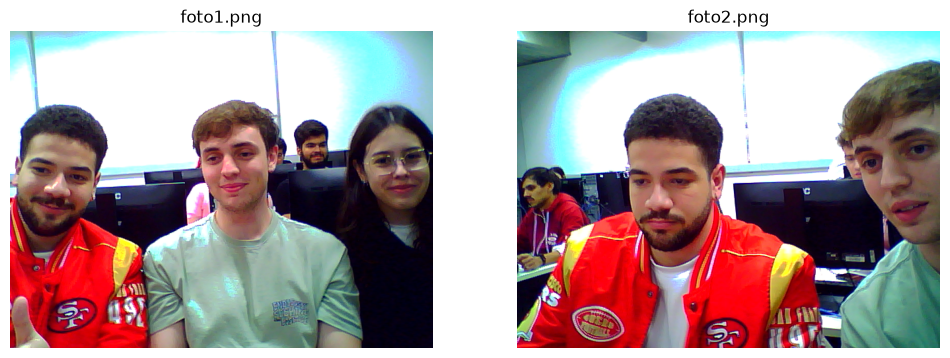

In [2]:
# Imagens utilizadas
img1_color = cv.imread('foto1.png')
img2_color = cv.imread('foto2.png')

img1_rgb = cv.cvtColor(img1_color, cv.COLOR_BGR2RGB)
img2_rgb = cv.cvtColor(img2_color, cv.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img1_rgb)
plt.title('foto1.png')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img2_rgb)
plt.title('foto2.png')
plt.axis('off')
plt.show()

### Parte 2A - SIFT em imagens salvas

Nesta etapa, o programa lê duas imagens previamente salvas e as converte para escala de cinza. Em seguida, o algoritmo SIFT é utilizado para detectar pontos-chave e extrair descritores. As correspondências entre os descritores são realizadas com o FLANN e filtradas pelo teste da razão de Lowe. Por fim, a homografia é estimada por meio do método RANSAC, possibilitando localizar o objeto nas imagens e exibir as correspondências válidas encontradas.

Pontos-chave imagem 1: 1096
Pontos-chave imagem 2: 1338
Boas correspondencias: 40
Resultado salvo em: resultado_parte2_A.png


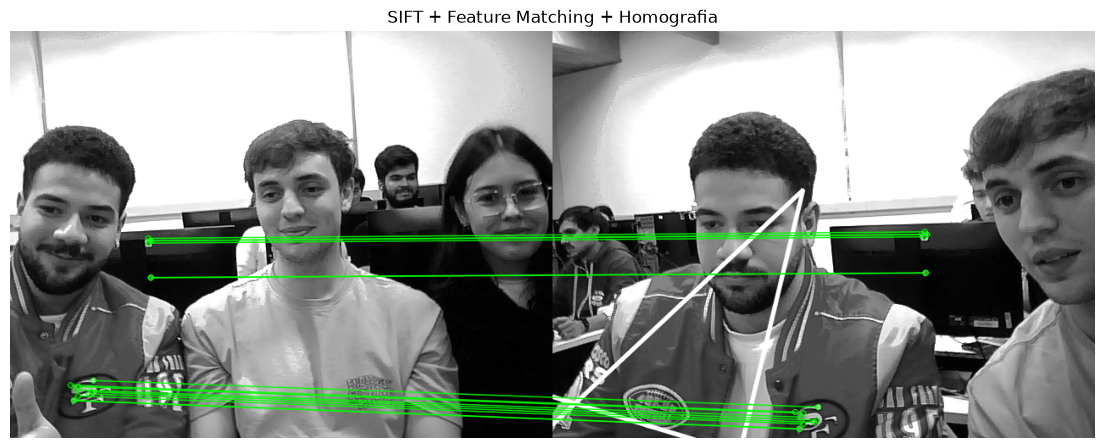

In [3]:
# ============================================================
# LAB 2 - PARTE 2A
# SIFT + Feature Matching + Homografia usando imagens salvas
#
# IMPORTANTE:
# Este codigo apenas LE as imagens foto1.png e foto2.png.
# Ele NAO sobrescreve as imagens originais.
# O resultado e salvo em resultado_parte2_A.png.
# ============================================================

MIN_MATCH_COUNT = 10

# Imagens tiradas no laboratorio
IMG1_PATH = "foto1.png"   # imagem de consulta
IMG2_PATH = "foto2.png"   # imagem de busca
OUT_PATH = "resultado_parte2_A.png"

# Ler imagens em escala de cinza
img1 = cv.imread(IMG1_PATH, cv.IMREAD_GRAYSCALE)
img2 = cv.imread(IMG2_PATH, cv.IMREAD_GRAYSCALE)

# Verificar se as imagens foram carregadas
if img1 is None:
    print(f"Erro: nao foi possivel abrir {IMG1_PATH}")
    exit()

if img2 is None:
    print(f"Erro: nao foi possivel abrir {IMG2_PATH}")
    exit()

# Criar detector SIFT
sift = cv.SIFT_create()

# Detectar pontos-chave e descritores
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

if des1 is None or des2 is None:
    print("Erro: nao foram encontrados descritores suficientes.")
    exit()

# Configurar FLANN Matcher
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann = cv.FlannBasedMatcher(index_params, search_params)

# Encontrar correspondencias entre os descritores
matches = flann.knnMatch(des1, des2, k=2)

# Aplicar o teste de Lowe para manter boas correspondencias
good = []
for m, n in matches:
    if m.distance < 0.7 * n.distance:
        good.append(m)

print(f"Pontos-chave imagem 1: {len(kp1)}")
print(f"Pontos-chave imagem 2: {len(kp2)}")
print(f"Boas correspondencias: {len(good)}")

# Calcular homografia se houver matches suficientes
if len(good) > MIN_MATCH_COUNT:
    src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

    M, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 5.0)

    if M is not None and mask is not None:
        matchesMask = mask.ravel().tolist()

        h, w = img1.shape
        pts = np.float32([[0, 0], [0, h-1], [w-1, h-1], [w-1, 0]]).reshape(-1, 1, 2)
        dst = cv.perspectiveTransform(pts, M)

        img2_result = cv.polylines(img2.copy(), [np.int32(dst)], True, 255, 3, cv.LINE_AA)
    else:
        print("Homografia nao foi calculada corretamente.")
        matchesMask = None
        img2_result = img2.copy()
else:
    print("Not enough matches are found - {}/{}".format(len(good), MIN_MATCH_COUNT))
    matchesMask = None
    img2_result = img2.copy()

# Desenhar correspondencias
draw_params = dict(
    matchColor=(0, 255, 0),
    singlePointColor=None,
    matchesMask=matchesMask,
    flags=2
)

img3 = cv.drawMatches(img1, kp1, img2_result, kp2, good, None, **draw_params)

# Salvar resultado sem alterar as imagens originais
cv.imwrite(OUT_PATH, img3)
print(f"Resultado salvo em: {OUT_PATH}")

# Mostrar resultado
plt.figure(figsize=(14, 7))
plt.imshow(img3, cmap="gray")
plt.title("SIFT + Feature Matching + Homografia")
plt.axis("off")
plt.show()

### Parte 2B - Leitura de duas webcams

Na segunda parte, o código foi adaptado para abrir duas câmeras simultaneamente no mesmo computador. A cada leitura das webcams, os frames são convertidos para escala de cinza e processados pelo SIFT. O resultado mostra as correspondências entre as imagens das duas câmeras.

Para preservar as imagens capturadas durante a realização do experimento, o código foi ajustado para não sobrescrever os arquivos camera0_objeto.png e camera1_objeto.png, uma vez que essas imagens apresentaram boa qualidade e foram utilizadas no relatório. Caso seja necessário registrar uma evidência da execução do programa, apenas o quadro final contendo o resultado da correspondência é salvo no arquivo resultado_parte2_B_frame.png.

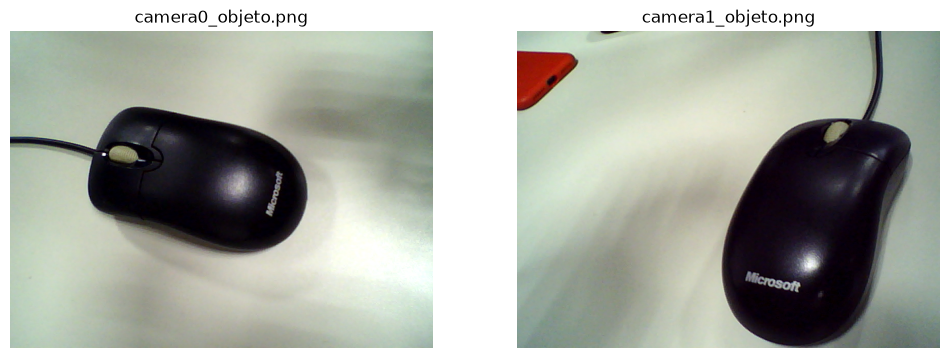

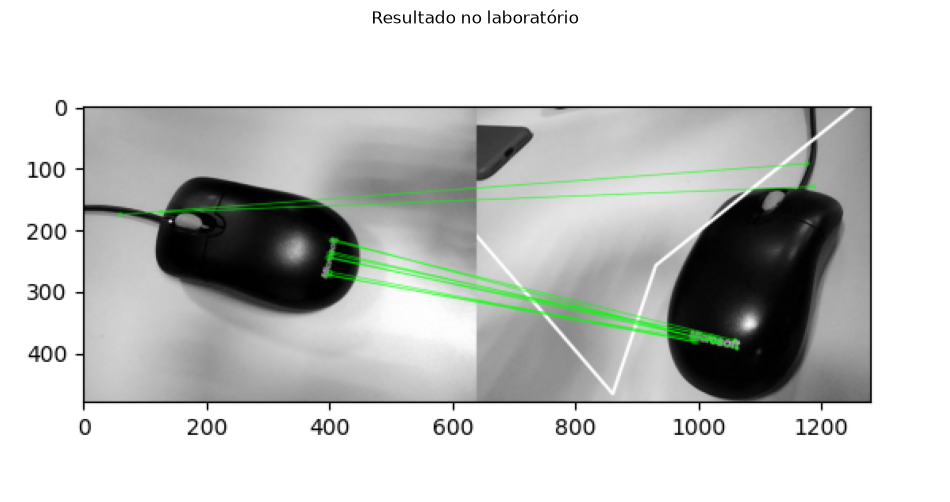

In [7]:
# Imagens salvas durante a execução com duas webcams
cam0_img = cv.imread('camera0_objeto.png')
cam1_img = cv.imread('camera1_objeto.png')
resultado = cv.imread('resultado_parte2B.png')

cam0_rgb = cv.cvtColor(cam0_img, cv.COLOR_BGR2RGB)
cam1_rgb = cv.cvtColor(cam1_img, cv.COLOR_BGR2RGB)
resultado_rgb = cv.cvtColor(resultado, cv.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(cam0_rgb)
plt.title('camera0_objeto.png')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cam1_rgb)
plt.title('camera1_objeto.png')
plt.axis('off')
plt.show()

plt.subplot(1, 1, 1)
plt.imshow(resultado_rgb)
plt.title('Resultado no laboratório')
plt.axis('off')
plt.show()

In [ ]:
# ============================================================
# LAB 2 - PARTE 2B
# SIFT + Feature Matching usando duas webcams
#
# IMPORTANTE:
# Este codigo NÃO sobrescreve as imagens originais.
# Ele mostra o resultado em video.
# Para salvar um frame do resultado, pressione 's'.
# O arquivo salvo sera resultado_parte2_B_frame.png.
#
# Para sair, pressione 'q'.
# ============================================================

MIN_MATCH_COUNT = 10
CAMERA_0 = 0
CAMERA_1 = 1
OUT_FRAME = "resultado_parte2_B_frame.png"

# Criar detector SIFT
sift = cv.SIFT_create()

# Configurar FLANN Matcher
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann = cv.FlannBasedMatcher(index_params, search_params)


def aplicar_sift_matching(frame0, frame1):
    """Aplica SIFT + matching em dois frames e retorna a imagem final."""

    gray0 = cv.cvtColor(frame0, cv.COLOR_BGR2GRAY)
    gray1 = cv.cvtColor(frame1, cv.COLOR_BGR2GRAY)

    kp0, des0 = sift.detectAndCompute(gray0, None)
    kp1, des1 = sift.detectAndCompute(gray1, None)

    if des0 is None or des1 is None:
        return np.hstack((gray0, gray1)), 0, 0, 0

    matches = flann.knnMatch(des0, des1, k=2)

    good = []
    for m, n in matches:
        if m.distance < 0.7 * n.distance:
            good.append(m)

    matchesMask = None
    gray1_result = gray1.copy()

    if len(good) > MIN_MATCH_COUNT:
        src_pts = np.float32([kp0[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp1[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

        M, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 5.0)

        if M is not None and mask is not None:
            matchesMask = mask.ravel().tolist()

            h, w = gray0.shape
            pts = np.float32([[0, 0], [0, h-1], [w-1, h-1], [w-1, 0]]).reshape(-1, 1, 2)
            dst = cv.perspectiveTransform(pts, M)
            gray1_result = cv.polylines(gray1.copy(), [np.int32(dst)], True, 255, 3, cv.LINE_AA)

    draw_params = dict(
        matchColor=(0, 255, 0),
        singlePointColor=None,
        matchesMask=matchesMask,
        flags=2
    )

    resultado = cv.drawMatches(gray0, kp0, gray1_result, kp1, good, None, **draw_params)

    texto = f"kp0={len(kp0)}  kp1={len(kp1)}  good={len(good)}"
    cv.putText(resultado, texto, (20, 30), cv.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

    return resultado, len(kp0), len(kp1), len(good)


# Abrir as duas cameras
cam0 = cv.VideoCapture(CAMERA_0)
cam1 = cv.VideoCapture(CAMERA_1)

if not cam0.isOpened():
    print("Erro: nao foi possivel abrir a camera 0.")
    exit()

if not cam1.isOpened():
    print("Erro: nao foi possivel abrir a camera 1.")
    print("Tente trocar CAMERA_1 para 2 ou 3.")
    cam0.release()
    exit()

print("Cameras abertas com sucesso.")
print("Pressione 's' para salvar apenas o frame do resultado.")
print("Pressione 'q' para sair.")

while True:
    ret0, frame0 = cam0.read()
    ret1, frame1 = cam1.read()

    if not ret0 or not ret1:
        print("Erro ao capturar frame de uma das cameras.")
        break

    resultado, n0, n1, ngood = aplicar_sift_matching(frame0, frame1)

    cv.imshow("Parte 2B - SIFT em duas webcams", resultado)

    tecla = cv.waitKey(1) & 0xFF

    if tecla == ord('s'):
        cv.imwrite(OUT_FRAME, resultado)
        print(f"Frame do resultado salvo em: {OUT_FRAME}")

    if tecla == ord('q'):
        print("Programa encerrado.")
        break

cam0.release()
cam1.release()
cv.destroyAllWindows()

## 4. Análise e Discussão

Na Parte 2A, o SIFT encontrou pontos-chave nas duas imagens e gerou correspondências entre regiões semelhantes do objeto. Como o objeto aparece com mudança de posição e rotação, o experimento evidencia a utilidade de descritores locais robustos. A aplicação do teste de Lowe reduziu correspondências ambíguas, enquanto o RANSAC permitiu estimar a homografia ignorando parte dos outliers.

Na Parte 2B, a mesma lógica foi adaptada para duas webcams. Como as câmeras observam a cena de pontos de vista diferentes, as correspondências dependem da existência de regiões texturizadas e visíveis nas duas imagens. Objetos com pouca textura, reflexos ou iluminação irregular podem reduzir o número de correspondências corretas. Mesmo assim, a técnica é útil para problemas de visão estéreo, rastreamento, reconstrução 3D, alinhamento de imagens e reconhecimento de objetos.

No contexto de um trabalho final, a detecção de features pode ser usada para identificar objetos de interesse em vídeo, comparar cenas capturadas por câmeras diferentes, auxiliar em calibração, estimar deslocamentos entre frames ou reconhecer objetos a partir de pontos característicos.


## 5. Conclusões

O Laboratório 2 permitiu compreender a importância das features locais em visão computacional. O método SIFT foi capaz de detectar e descrever pontos relevantes nas imagens, permitindo encontrar correspondências entre diferentes visualizações do mesmo objeto. A homografia estimada a partir das correspondências possibilitou localizar a região correspondente do objeto na segunda imagem.

A adaptação para duas webcams mostrou que o mesmo procedimento pode ser aplicado em vídeo, embora o desempenho dependa da qualidade da captura, iluminação, textura do objeto e diferença de ponto de vista entre as câmeras. Assim, a extração de características se mostra uma ferramenta fundamental para reconhecimento de objetos, alinhamento de imagens, visão estéreo e reconstrução tridimensional.


## Referências

KADHIM, Haydar Abdulameer; ARAHEEMAH, Waleed Abdullah. A method to improve corner detectors (Harris, Shi-Tomasi & FAST) using adaptive contrast enhancement filter. **Periodicals of Engineering and Natural Sciences**, v. 8, n. 1, p. 508-515, 2020.

KURASHIMA, Celso. **Pontos de Interesse - Features**. 2026. Apresentação em PowerPoint.

LOWE, David G. Distinctive image features from scale-invariant keypoints. **International journal of computer vision**, v. 60, n. 2, p. 91-110, 2004.

NIXON, Mark; AGUADO, Alberto S. **Feature extraction and image processing for computer vision**. Academic press, 2025.

NOBLE, Frazer K. Comparison of OpenCV's feature detectors and feature matchers. In: **2016 23rd International Conference on Mechatronics and Machine Vision in Practice (M2VIP)**. IEEE, 2016. p. 1-6.

OpenCV. **Feature Detection and Description**. Disponível em: <https://docs.opencv.org/4.13.0/d6/d1d/group__cudafeatures2d.html>.

OpenCV. **Feature Matching + Homography to find Objects**. Disponível em: <https://docs.opencv.org/4.x/d1/de0/tutorial_py_feature_homography.html>.

SZELISKI, Richard. **Computer vision: algorithms and applications**. Springer Nature, 2022.

WU, Jian et al. A Comparative Study of SIFT and its Variants. **Measurement science review**, v. 13, n. 3, p. 122-131, 2013.